In [1]:
import sys, importlib
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import logging

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(name)s | %(message)s")
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

from src.config import cfg
from src.data.loader import load_features
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# FORCE reload to ensure Jupyter sees the latest train.py updates
import src.models.train as train_module
importlib.reload(train_module)
from src.models.train import compare_models, train_final_model, save_model, load_model, time_series_cv, compute_metrics, CANDIDATE_MODELS

df = load_features()

# Dynamically identify all targets and features
target_cols = [c for c in df.columns if c.startswith("temp_c_next_")]
feature_cols = [c for c in df.columns if c not in target_cols]

print(f"Feature matrix: {df.shape}")
print(f"Targets found ({len(target_cols)}): {target_cols}")

INFO | src.data.loader | Loading features from: C:\Users\CDAC\Documents\AI\weather\data\features\weather_features.parquet
INFO | src.data.loader | Loaded features: (8658, 37)


Feature matrix: (8658, 37)
Targets found (5): ['temp_c_next_1h', 'temp_c_next_6h', 'temp_c_next_12h', 'temp_c_next_24h', 'temp_c_next_48h']


In [2]:
# This is the core evaluation. Takes ~2-3 minutes on a laptop.
print("Running model comparison (this trains each model across 5 CV folds)...\n")
comparison = compare_models(df)

INFO | src.models.train | Persistence baseline: MAE=0.495°C  RMSE=0.726  R²=0.9788
INFO | src.models.train | 
Training ridge...
INFO | src.models.train |   Fold 1/5 (train=1,443  test=1,443) MAE=0.527  R²=0.9840
INFO | src.models.train |   Fold 2/5 (train=2,886  test=1,443) MAE=0.450  R²=0.9868
INFO | src.models.train |   Fold 3/5 (train=4,329  test=1,443) MAE=0.443  R²=0.9834
INFO | src.models.train |   Fold 4/5 (train=5,772  test=1,443) MAE=0.384  R²=0.9902
INFO | src.models.train |   Fold 5/5 (train=7,215  test=1,443) MAE=0.318  R²=0.9899
INFO | src.models.train |   ridge: MAE=0.424  RMSE=0.591  R²=0.9869
INFO | src.models.train | 
Training random_forest...


Running model comparison (this trains each model across 5 CV folds)...



INFO | src.models.train |   Fold 1/5 (train=1,443  test=1,443) MAE=1.028  R²=0.9227
INFO | src.models.train |   Fold 2/5 (train=2,886  test=1,443) MAE=0.926  R²=0.9293
INFO | src.models.train |   Fold 3/5 (train=4,329  test=1,443) MAE=0.745  R²=0.9319
INFO | src.models.train |   Fold 4/5 (train=5,772  test=1,443) MAE=0.424  R²=0.9877
INFO | src.models.train |   Fold 5/5 (train=7,215  test=1,443) MAE=0.354  R²=0.9873
INFO | src.models.train |   random_forest: MAE=0.695  RMSE=1.084  R²=0.9518
INFO | src.models.train | 
Training gradient_boosting...
INFO | src.models.train |   Fold 1/5 (train=1,443  test=1,443) MAE=1.112  R²=0.9029
INFO | src.models.train |   Fold 2/5 (train=2,886  test=1,443) MAE=1.064  R²=0.9091
INFO | src.models.train |   Fold 3/5 (train=4,329  test=1,443) MAE=0.769  R²=0.9166
INFO | src.models.train |   Fold 4/5 (train=5,772  test=1,443) MAE=0.427  R²=0.9883
INFO | src.models.train |   Fold 5/5 (train=7,215  test=1,443) MAE=0.369  R²=0.9870
INFO | src.models.train |  

In [3]:
print("\n" + "=" * 58)
print("MODEL COMPARISON — sorted by MAE ascending")
print("=" * 58)
print(comparison.to_string(index=False))
print("=" * 58)
print(f"\nBest model: {comparison.iloc[0]['model']}  "
      f"(MAE={comparison.iloc[0]['mae']:.3f}°C)")

# ✅ Fixed: matches the name in compare_models()
baseline_row = comparison.loc[comparison["model"] == "persistence_baseline", "mae"]

if baseline_row.empty:
    # Safety net — prints available names so you can see what changed
    print(f"\nAvailable model names: {comparison['model'].tolist()}")
    print("Update the baseline name above to match.")
else:
    baseline_mae = baseline_row.values[0]
    best_mae     = comparison.iloc[0]["mae"]
    improvement  = (baseline_mae - best_mae) / baseline_mae * 100
    print(f"Persistence baseline MAE : {baseline_mae:.3f}°C")
    print(f"Best model MAE           : {best_mae:.3f}°C")
    print(f"Improvement over baseline: {improvement:.1f}%")


MODEL COMPARISON — sorted by MAE ascending
   mae   rmse    mape     r2                model
0.4243 0.5914 18.5999 0.9869                ridge
0.4951 0.7264 78.1293 0.9788 persistence_baseline
0.6954 1.0841 21.7388 0.9518        random_forest
0.7480 1.1874 25.4565 0.9408    gradient_boosting

Best model: ridge  (MAE=0.424°C)
Persistence baseline MAE : 0.495°C
Best model MAE           : 0.424°C
Improvement over baseline: 14.3%


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ["mae", "rmse", "r2"]
titles = ["MAE (°C) ↓ lower is better",
          "RMSE (°C) ↓ lower is better",
          "R² ↑ higher is better"]

# ✅ Updated key to match compare_models() output
colors = {
    "persistence_baseline": "#888780",
    "ridge":                "#B5D4F4",
    "random_forest":        "#1D9E75",
    "gradient_boosting":    "#185FA5",
}

# ✅ Updated name
BASELINE_NAME = "persistence_baseline"

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    bars = ax.bar(
        comparison["model"],
        comparison[metric],
        color=[colors.get(m, "#ccc") for m in comparison["model"]],
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_title(title)
    ax.set_xticklabels(comparison["model"], rotation=20, ha="right", fontsize=9)

    # Label bar values
    for bar, val in zip(bars, comparison[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8,
        )

    # ✅ Mark baseline with safe lookup
    baseline_row = comparison.loc[comparison["model"] == BASELINE_NAME, metric]
    if not baseline_row.empty:
        ax.axhline(
            baseline_row.values[0],
            color="#E24B4A", lw=1.5, ls="--", alpha=0.7,
            label="Persistence baseline"
        )
        ax.legend(fontsize=8)

plt.suptitle("Model comparison across CV folds", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Train on first 80%, predict on last 20%
X = df[feature_cols].values
y = df[target_cols].values  # y is now a 2D array!

split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = df.index[split:]

best_name = comparison.iloc[0]["model"]
best_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  CANDIDATE_MODELS[best_name]),
])

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

# ── Select the 24-hour horizon to visualize ──────────────────────
HORIZON_TO_PLOT = "temp_c_next_24h"
target_idx = target_cols.index(HORIZON_TO_PLOT)

y_test_h = y_test[:, target_idx]
y_pred_h = y_pred[:, target_idx]

test_metrics = compute_metrics(y_test_h, y_pred_h)

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# Full test period
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(dates_test, y_test_h, lw=0.8, color="#185FA5", alpha=0.8, label="Actual")
ax1.plot(dates_test, y_pred_h, lw=0.8, color="#E24B4A", alpha=0.8, label="Predicted")
ax1.set_title(f"{best_name} — actual vs predicted ({HORIZON_TO_PLOT})")
ax1.set_ylabel("Temperature (°C)")
ax1.legend()

# Zoom in on one week
ax2 = fig.add_subplot(gs[1, 0])
test_start = dates_test[0]
zoom_start = test_start + pd.Timedelta("7d")
zoom_end   = zoom_start + pd.Timedelta("7d")
week_mask = (dates_test >= zoom_start) & (dates_test < zoom_end)

ax2.plot(dates_test[week_mask], y_test_h[week_mask], lw=1.5, color="#185FA5", label="Actual")
ax2.plot(dates_test[week_mask], y_pred_h[week_mask], lw=1.5, color="#E24B4A", ls="--", label="Predicted")
ax2.set_title(f"Zoom: {zoom_start.date()} – {zoom_end.date()}")
ax2.set_ylabel("°C")
ax2.legend()

# Residuals
residuals = y_test_h - y_pred_h
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(residuals, bins=60, color="#1D9E75", alpha=0.8, edgecolor="white")
ax3.axvline(0, color="#E24B4A", lw=1.5, ls="--")
ax3.axvline(residuals.mean(), color="#185FA5", lw=1.5, label=f"Mean={residuals.mean():.3f}°C")
ax3.set_title("Residual distribution")
ax3.legend()

plt.suptitle(f"Multi-Output: {HORIZON_TO_PLOT}  |  MAE={test_metrics['mae']:.3f}°C", fontsize=13)
plt.show()

Generating SHAP explanation for horizon: temp_c_next_1h


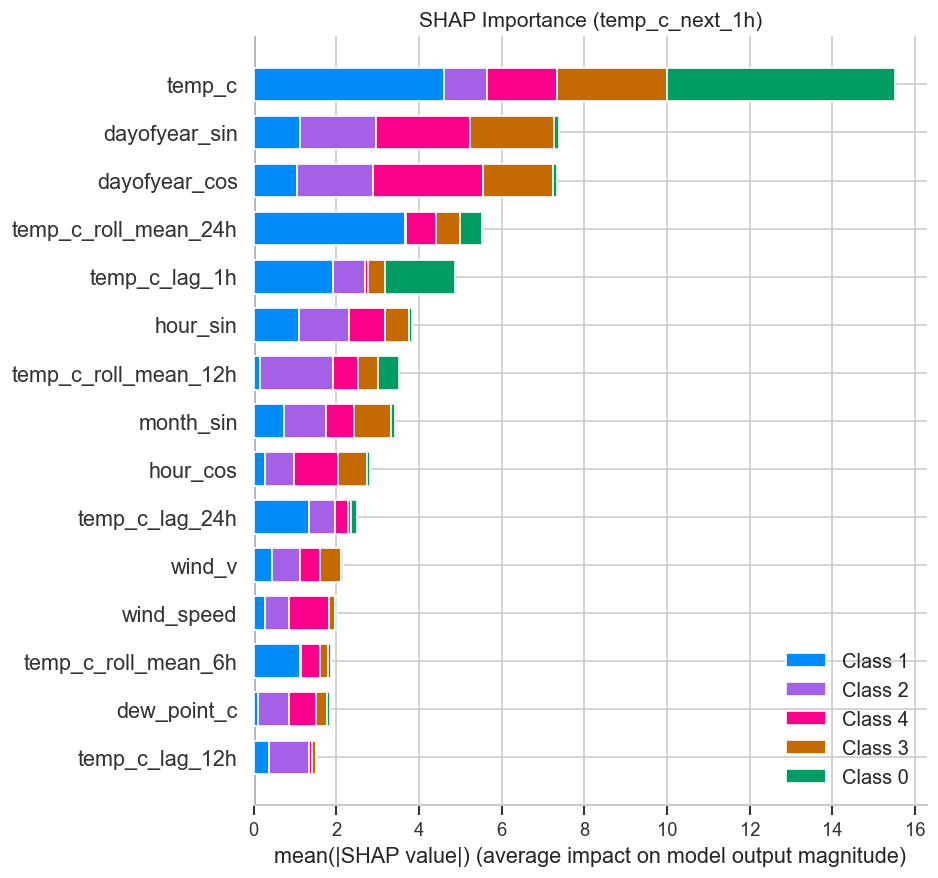

<Figure size 1200x960 with 0 Axes>

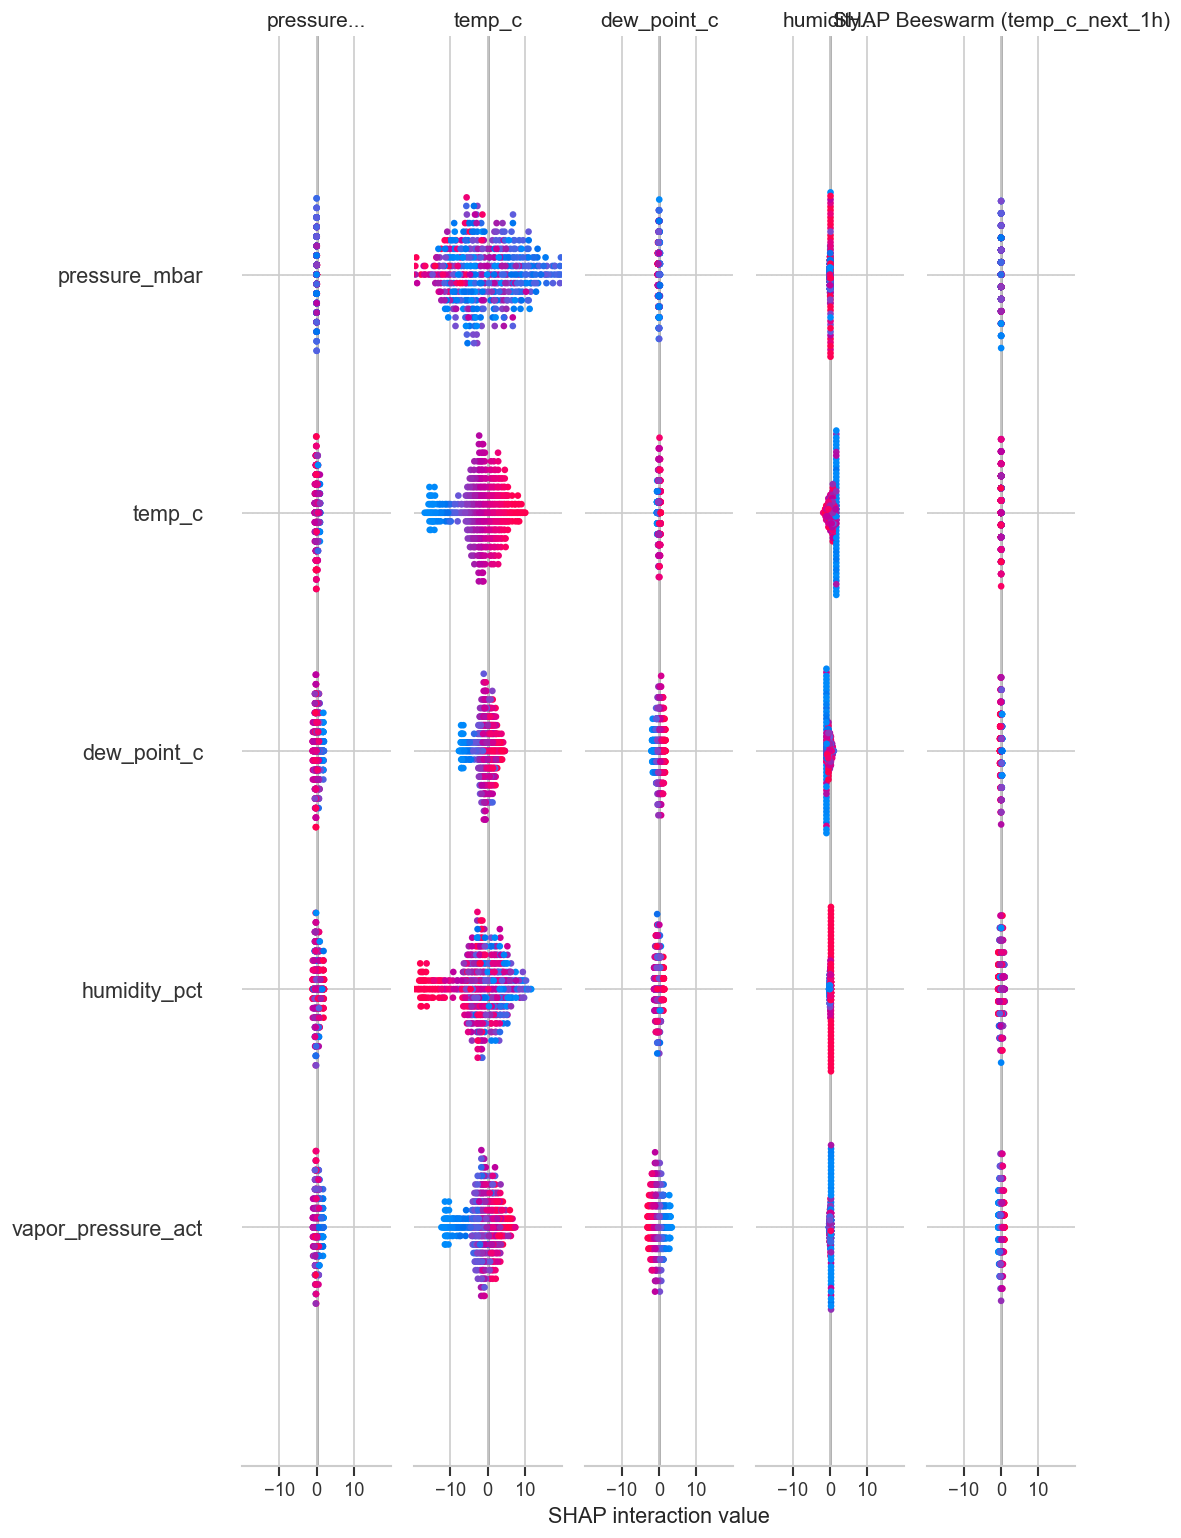

In [6]:
import shap

shap_sample = df[feature_cols].iloc[split:split+500]
model = best_pipe.named_steps["model"]
scaler = best_pipe.named_steps["scaler"]

X_scaled = scaler.transform(df[feature_cols].values)
X_shap_scaled = scaler.transform(shap_sample.values)

model_type = type(model).__name__

# Generate SHAP values
if model_type == "Ridge":
    explainer = shap.LinearExplainer(model, X_scaled)
    shap_vals = explainer.shap_values(X_shap_scaled)
else:
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_shap_scaled)

# ── CRITICAL FIX FOR MULTI-OUTPUT ──────────────────────────────────────────
# Multi-output models return a list of SHAP values (one for each horizon).
# We will explain the 1-hour horizon (index 0).
HORIZON_INDEX = 0
print(f"Generating SHAP explanation for horizon: {target_cols[HORIZON_INDEX]}")

if isinstance(shap_vals, list):
    shap_vals_to_plot = shap_vals[HORIZON_INDEX]
else:
    shap_vals_to_plot = shap_vals  # Fallback for some linear models

# Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals_to_plot,
    shap_sample,
    feature_names=feature_cols,
    plot_type="bar",
    max_display=15,
    show=False,
)
plt.gca().set_title(f"SHAP Importance ({target_cols[HORIZON_INDEX]})")
plt.tight_layout()
plt.show()

# Beeswarm Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals_to_plot,
    shap_sample,
    feature_names=feature_cols,
    max_display=15,
    show=False,
)
plt.gca().set_title(f"SHAP Beeswarm ({target_cols[HORIZON_INDEX]})")
plt.tight_layout()
plt.show()

In [ ]:
import joblib

best_model_name = comparison.iloc[0]["model"]
print(f"Training final Multi-Output model: {best_model_name}")
print(f"Horizons: {target_cols}")

# Fit on ALL data
best_pipe.fit(df[feature_cols].values, df[target_cols].values)

best_cv_metrics = {
    "mae":  comparison.iloc[0]["mae"],
    "rmse": comparison.iloc[0]["rmse"],
    "mape": comparison.iloc[0]["mape"],
    "r2":   comparison.iloc[0]["r2"],
}

# Explicitly save target_cols inside the artifact!
artifact = {
    "pipeline":      best_pipe,
    "feature_cols":  feature_cols,
    "target_cols":   target_cols,     # <-- The API needs this list!
    "model_version": cfg.model_version,
    "cv_metrics":    best_cv_metrics,
}

cfg.model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(artifact, cfg.model_path)

print(f"\n✅ Multi-Output Artifact saved to: {cfg.model_path}")
print(f"   Features: {len(artifact['feature_cols'])}")
print(f"   Targets : {len(artifact['target_cols'])}")